<a href="https://colab.research.google.com/github/jabermaslaoui1/lda-exercise/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

Data is ready!
Accuracy: 90.00%


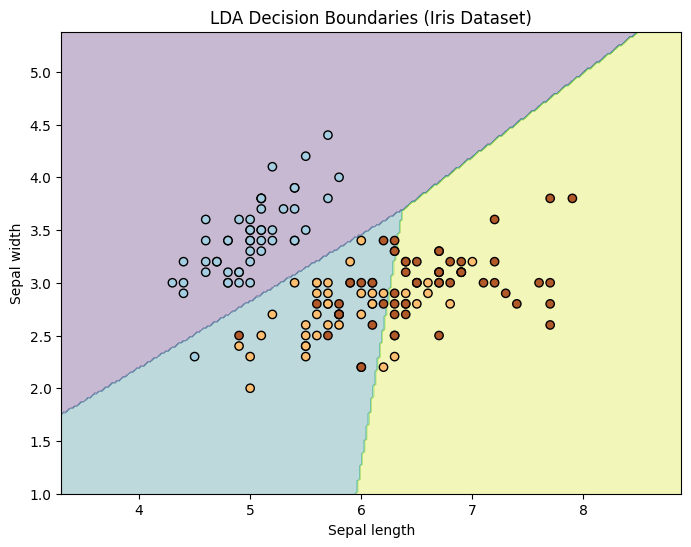

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load the famous Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # We only take the first two features (Sepal length/width) to keep it 2D
y = iris.target

# 2. Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data is ready!")

# 3. Initialize and Train the LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 4. Make predictions
y_pred = lda.predict(X_test)

# 5. Check accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

import numpy as np

# Create a mesh grid to plot the decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('LDA Decision Boundaries (Iris Dataset)')
plt.show()